In [38]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
reg_data = pd.read_csv('audi.csv')
class_data = pd.read_csv('weatherAUS.csv')

# Regression

In [38]:
reg_data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [39]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  object 
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  object 
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  object 
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 750.2+ KB


In [40]:
reg_data.describe()

,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


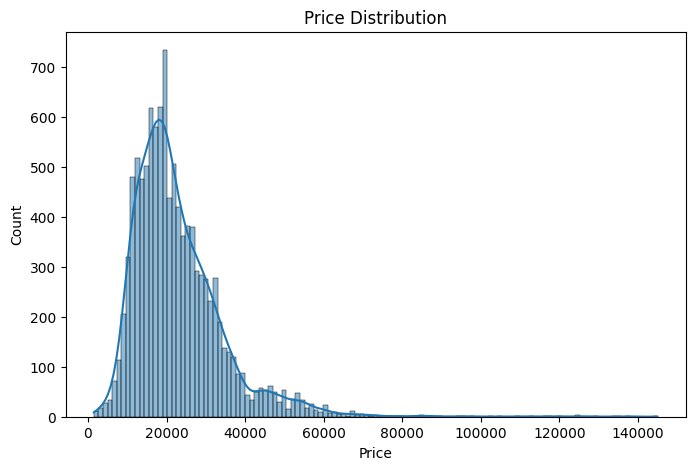

In [ ]:
# Визуализация распределения цены (целевой переменной).
plt.figure(figsize=(8,5))
sns.histplot(reg_data['price'], bins='auto', kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [ ]:
# Удаление объектов с ценой выше 75 000, так как на графике выше видно,
# что это единичные выбросы ("длинный хвост"), которые могут ухудшить обучение модели.
reg_data = reg_data[reg_data['price'] < 75000]

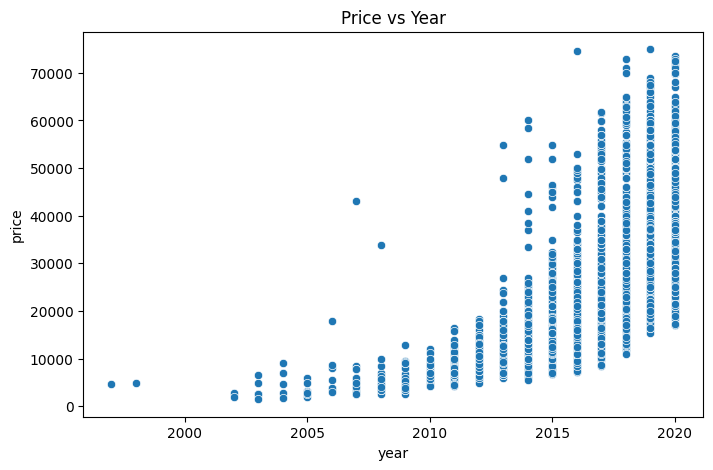

In [ ]:
# Построение графика рассеяния (scatterplot) для анализа зависимости цены от года выпуска.
# Ожидаемо: чем новее машина, тем она дороже.
plt.figure(figsize=(8,5))
sns.scatterplot(data=reg_data, x='year', y='price')
plt.title('Price vs Year')
plt.show()

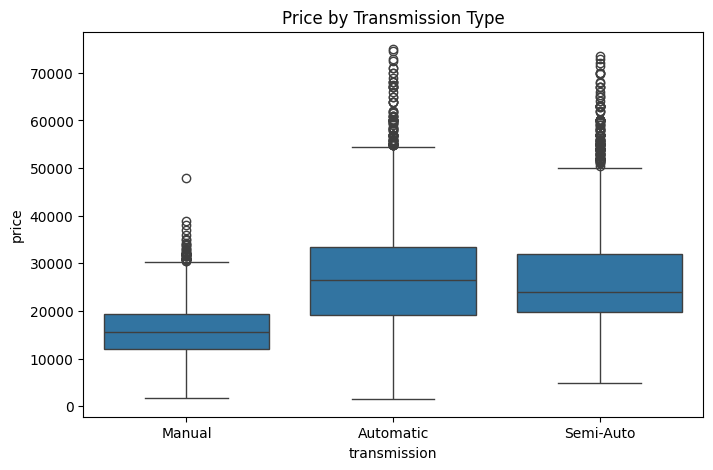

In [ ]:
# Boxplot для анализа цен в зависимости от типа коробки передач.
plt.figure(figsize=(8,5))
sns.boxplot(data=reg_data, x='transmission', y='price')
plt.title('Price by Transmission Type')
plt.show()

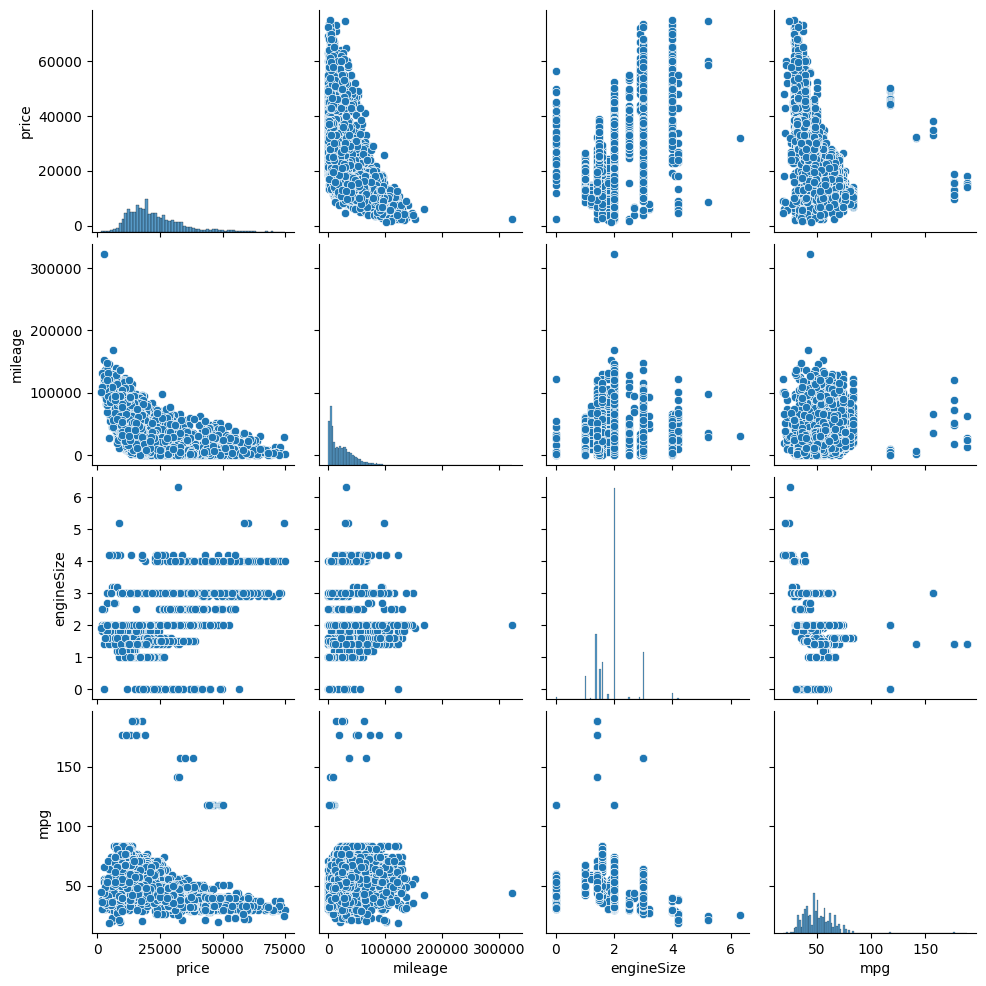

In [ ]:
# Pairplot для просмотра попарных зависимостей между числовыми признаками.
sns.pairplot(reg_data[['price', 'mileage', 'engineSize', 'mpg']])
plt.show()

In [ ]:
#Разделение признаков на категориальные (str_cols) и числовые (num_cols).
str_cols = ['model', 'transmission', 'fuelType']
num_cols = ['year', 'mileage', 'engineSize', 'mpg', 'tax']
target_col = 'price'

In [ ]:
# Инициализация кодировщика и скейлера.
te = TargetEncoder()
scaler = StandardScaler()

In [ ]:
# Разделение данных на признаки и целевую переменную.
X = reg_data.drop('price', axis=1)
y = reg_data['price']

In [ ]:
# Разделение выборки на обучающую и тестовую.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Инициализация модели для k ближайших соседей
model = KNeighborsRegressor(n_neighbors=5)

In [ ]:
# Создание трансформера для предобработки данных и обучение.
transformer = ColumnTransformer(transformers=[
    ('scaler', scaler, num_cols),
    ('cat', te, str_cols)
])


full_pipe = Pipeline([('preprocessing', transformer), ('model', model)])


full_pipe.fit(X_train, y_train)

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Предсказание на тестовой выборке.
y_pred = full_pipe.predict(X_test)

In [ ]:
# Оценка модели с использованием различных метрик.
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

RMSE: 2768.052025949499
MAE: 1886.2460959548448
R2: 0.9317281984554894
MSE: 7662112.018363124


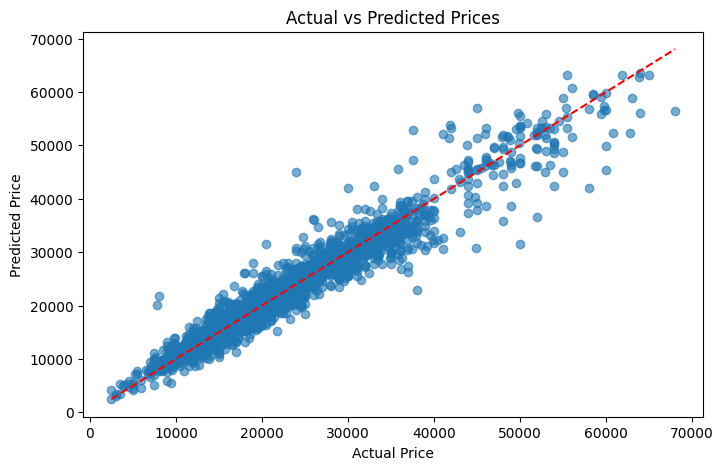

In [ ]:
# Визуализация фактических и предсказанных значений.
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [ ]:
# Оптимизация модели с использованием RandomizedSearchCV.
param_dist = {
    'model__n_neighbors': list(range(1,31)),
    'model__weights': ['uniform','distance'],
    'model__p': [1,2],
    'model__leaf_size': list(range(10,51))
}

rs = RandomizedSearchCV(full_pipe, param_distributions=param_dist, n_iter=10, cv=5,
                    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42)


In [ ]:
# Обучение модели с оптимальными параметрами.
rs.fit(X_train, y_train)
print('Best params:', rs.best_params_)
print('Best CV score (neg RMSE):', rs.best_score_)

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.

Best params: {'model__weights': 'uniform', 'model__p': 1, 'model__n_neighbors': 6, 'model__leaf_size': 17}
Best CV score (neg RMSE): -2619.812775103089


In [57]:
# Оценка на тестовой выборке
best_pipe = rs.best_estimator_
y_pred_rs = best_pipe.predict(X_test)
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rs)))
print('Test MAE:', mean_absolute_error(y_test, y_pred_rs))
print('Test R2:', r2_score(y_test, y_pred_rs))

Test RMSE: 2418.6165024974343
Test MAE: 1634.6993571652554
Test R2: 0.9478773017715125


In [ ]:
# Создание своего класса KnnRegressor
class KnnRegressor:
    def __init__(self, n_neighbors=5, weights='uniform', p=2, leaf_size=30):
        if weights not in ('uniform', 'distance'):
            raise ValueError("weights must be 'uniform' or 'distance'")
        self.n_neighbors = int(n_neighbors)
        self.weights = weights
        self.p = p
        self.leaf_size = leaf_size

        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
        y_arr = y.values if hasattr(y, 'values') else np.asarray(y)

        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(-1, 1)

        self.X_train = X_arr.astype(float)
        self.y_train = y_arr.ravel().astype(float)

        return self

    def _dist_single(self, x):

        diff = np.abs(self.X_train - x)

        if self.p == 1:
            return np.sum(diff, axis=1)
        elif self.p == 2:
            return np.sqrt(np.sum(diff * diff, axis=1))
        else:
            return np.sum(diff ** self.p, axis=1) ** (1.0 / self.p)

    def _predict_single(self, x):

        dists = self._dist_single(x)
        k = min(self.n_neighbors, len(dists))

        # выбираем индексы k ближайших
        idx_part = np.argpartition(dists, k-1)[:k]
        neigh_dists = dists[idx_part]

        # сортируем
        order = np.argsort(neigh_dists)
        neigh_idx = idx_part[order]
        neigh_dists_sorted = neigh_dists[order]

        neigh_y = self.y_train[neigh_idx]

        # uniform
        if self.weights == 'uniform':
            return np.mean(neigh_y)

        # distance
        eps = 1e-8
        exact_mask = neigh_dists_sorted == 0

        if np.any(exact_mask):
            return np.mean(neigh_y[exact_mask])

        weights = 1.0 / (neigh_dists_sorted + eps)
        return np.sum(weights * neigh_y) / np.sum(weights)

    def predict(self, X):
        if self.X_train is None:
            raise RuntimeError("Model has not been fitted yet.")

        Xq = X.values if hasattr(X, 'values') else np.asarray(X)
        if Xq.ndim == 1:
            Xq = Xq.reshape(1, -1)

        preds = np.zeros(Xq.shape[0], dtype=float)

        for i in range(len(Xq)):
            preds[i] = self._predict_single(Xq[i])

        return preds


In [ ]:
# Обучение и оценка модели KnnRegressor
transformer = ColumnTransformer(transformers=[
    ('scaler', scaler, num_cols),
    ('cat', te, str_cols)
])

full_pipe_custom = Pipeline([('preprocessing', transformer), ('model', KnnRegressor(n_neighbors=5))])
full_pipe_custom.fit(X_train, y_train)
y_pred_custom = full_pipe_custom.predict(X_test)
print('Test RMSE custom:', np.sqrt(mean_squared_error(y_test, y_pred_custom)))
print('Test MAE custom:', mean_absolute_error(y_test, y_pred_custom))
print('Test R2 custom:', r2_score(y_test, y_pred_custom))

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Test RMSE custom: 2763.963716483903
Test MAE custom: 1880.5941674506114
Test R2 custom: 0.9319297193284589


/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## Добавим пару новых фич

### Датасет был обновлён в 2020 году, поэтому возраст считается относительно 2021, чтобы не было деления на ноль

In [60]:
X['age'] = 2021 - X['year']

In [61]:
X['MileagePerYear'] = X['mileage'] / X['age']

In [62]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,age,MileagePerYear
0,A1,2017,Manual,15735,Petrol,150,55.4,1.4,4,3933.75
1,A6,2016,Automatic,36203,Diesel,20,64.2,2.0,5,7240.60
2,A1,2016,Manual,29946,Petrol,30,55.4,1.4,5,5989.20
3,A4,2017,Automatic,25952,Diesel,145,67.3,2.0,4,6488.00
4,A3,2019,Manual,1998,Petrol,145,49.6,1.0,2,999.00


In [63]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
str_cols = X.select_dtypes(include=['object']).columns.tolist()

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Обучение и оценка модели knn с новыми признаками
transformer = ColumnTransformer(transformers=[
    ('scaler', scaler, num_cols),
    ('cat', te, str_cols)
])

model = KNeighborsRegressor()


full_pipe = Pipeline([('preprocessing', transformer), ('model', model)])

In [ ]:
# Оптимизация с использованием RandomizedSearchCV.
param_dist = {
    'model__n_neighbors': list(range(1,31)),
    'model__weights': ['uniform','distance'],
    'model__p': [1,2],
    'model__leaf_size': list(range(10,51))
}

rs = RandomizedSearchCV(full_pipe, param_distributions=param_dist, n_iter=10, cv=5,
                    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42)

In [ ]:
# Обучение модели с оптимальными параметрами.
rs.fit(X_train, y_train)
print('Best params:', rs.best_params_)
print('Best CV score (neg RMSE):', rs.best_score_)

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.

Best params: {'model__weights': 'uniform', 'model__p': 1, 'model__n_neighbors': 6, 'model__leaf_size': 17}
Best CV score (neg RMSE): -2719.806410663631


In [68]:
# Оценка на тестовой выборке
best_pipe = rs.best_estimator_
y_pred_rs = best_pipe.predict(X_test)
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rs)))
print('Test MAE:', mean_absolute_error(y_test, y_pred_rs))
print('Test R2:', r2_score(y_test, y_pred_rs))

Test RMSE: 2581.700312217432
Test MAE: 1731.497412982126
Test R2: 0.940611204023096


# Classification

In [3]:
class_data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
class_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
class_data.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [6]:
class_data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


/var/folders/d0/0j41qjnd51vdsqjbyvxmlgyh0000gn/T/ipykernel_1011/2046854377.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')


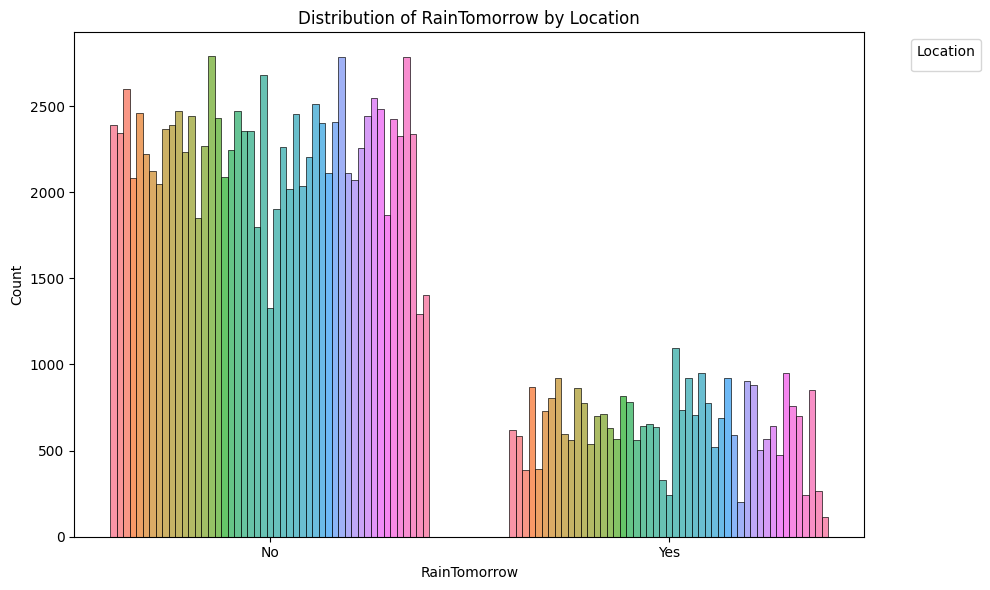

In [ ]:
# Визуализация распределения целевой переменной 'RainTomorrow' по локациям.
plt.figure(figsize=(10,6))
sns.histplot(data=class_data, x='RainTomorrow', hue='Location', multiple='dodge', shrink=0.8)
plt.title('Distribution of RainTomorrow by Location')
plt.xlabel('RainTomorrow')
plt.ylabel('Count')
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

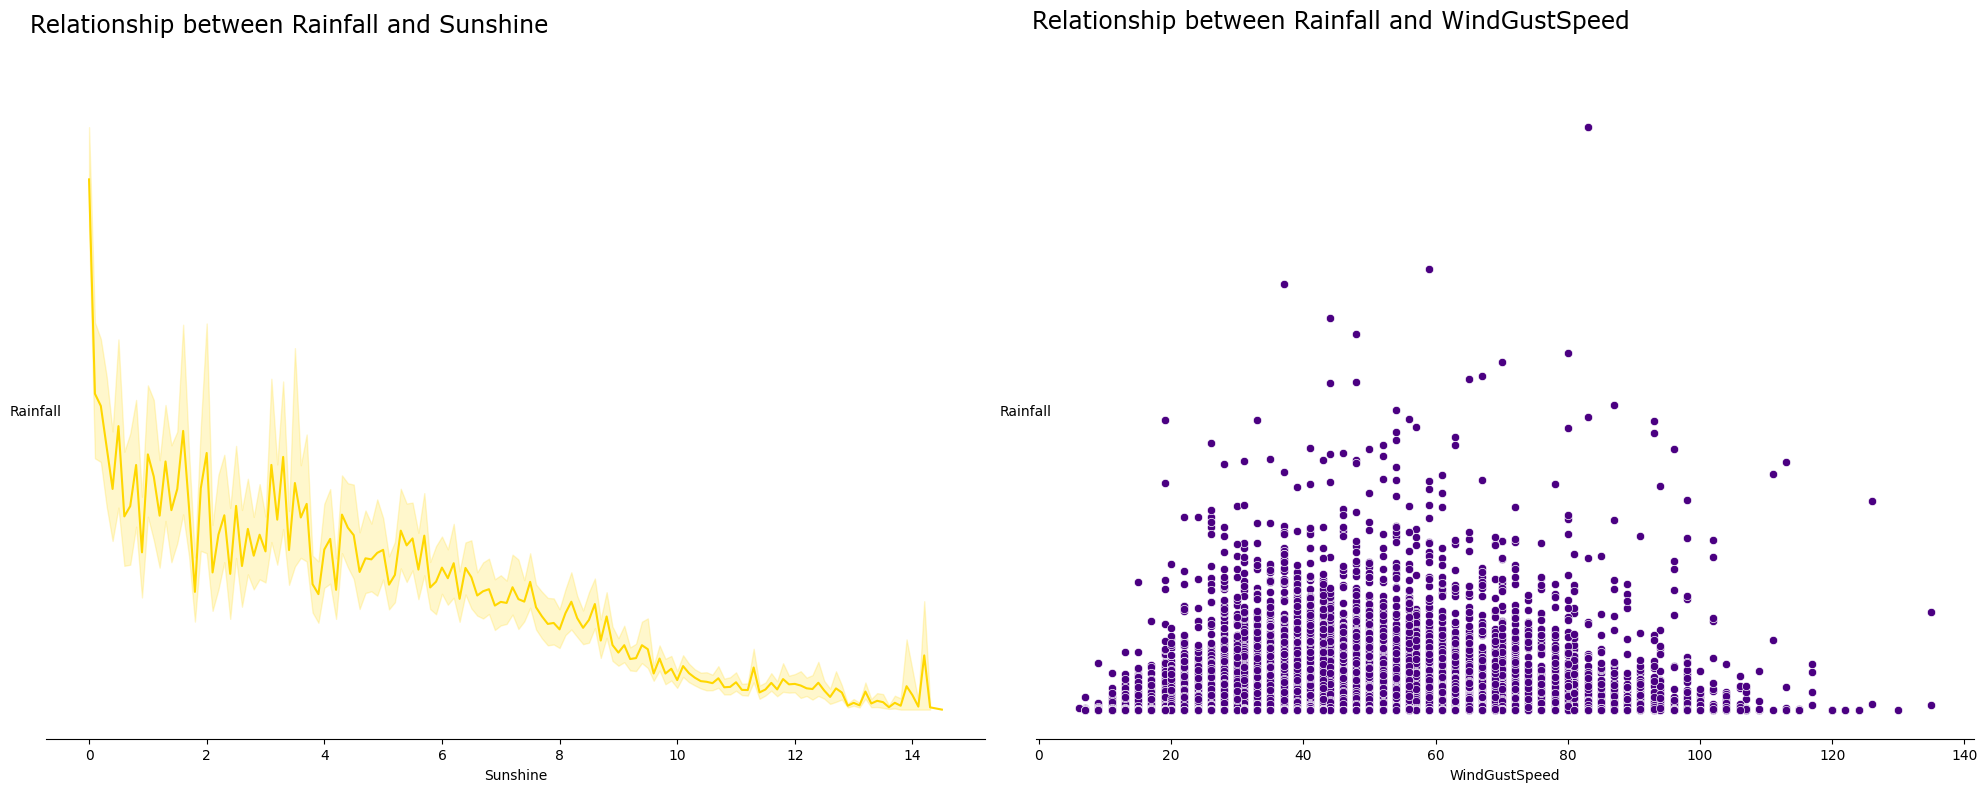

In [ ]:
# Визуализация зависимости между 'Rainfall' и 'Sunshine', а также 'Rainfall' и 'WindGustSpeed'.
fig=plt.figure(figsize=(20,8),facecolor='white')

gs=fig.add_gridspec(1,2)

ax=[_ for _ in range(2)]
ax[0]=fig.add_subplot(gs[0,0])
ax[1]=fig.add_subplot(gs[0,1])

ax[0].text(-1,15,"Relationship between Rainfall and Sunshine",fontsize=17,fontweight='normal', fontfamily='Verdana')

ax[1].text(-1,430,"Relationship between Rainfall and WindGustSpeed",fontsize=17,fontweight='normal', fontfamily='Verdana')

sns.lineplot(data=class_data,x='Sunshine',y='Rainfall',ax=ax[0],color='#FFD700')
sns.scatterplot(data=class_data,x='WindGustSpeed',y='Rainfall',ax=ax[1],color='#4B0082')

for i in range(2):
    
    ax[i].set_ylabel('Rainfall').set_rotation(0)
    ax[i].set_yticklabels('')
    ax[i].tick_params(axis='y',length=0)
    
    for direction in ['top','right','left']:
        ax[i].spines[direction].set_visible(False)
        
plt.tight_layout()
plt.show()

<Axes: xlabel='Cloud3pm', ylabel='Rainfall'>

<Axes: xlabel='Cloud3pm', ylabel='Rainfall'>

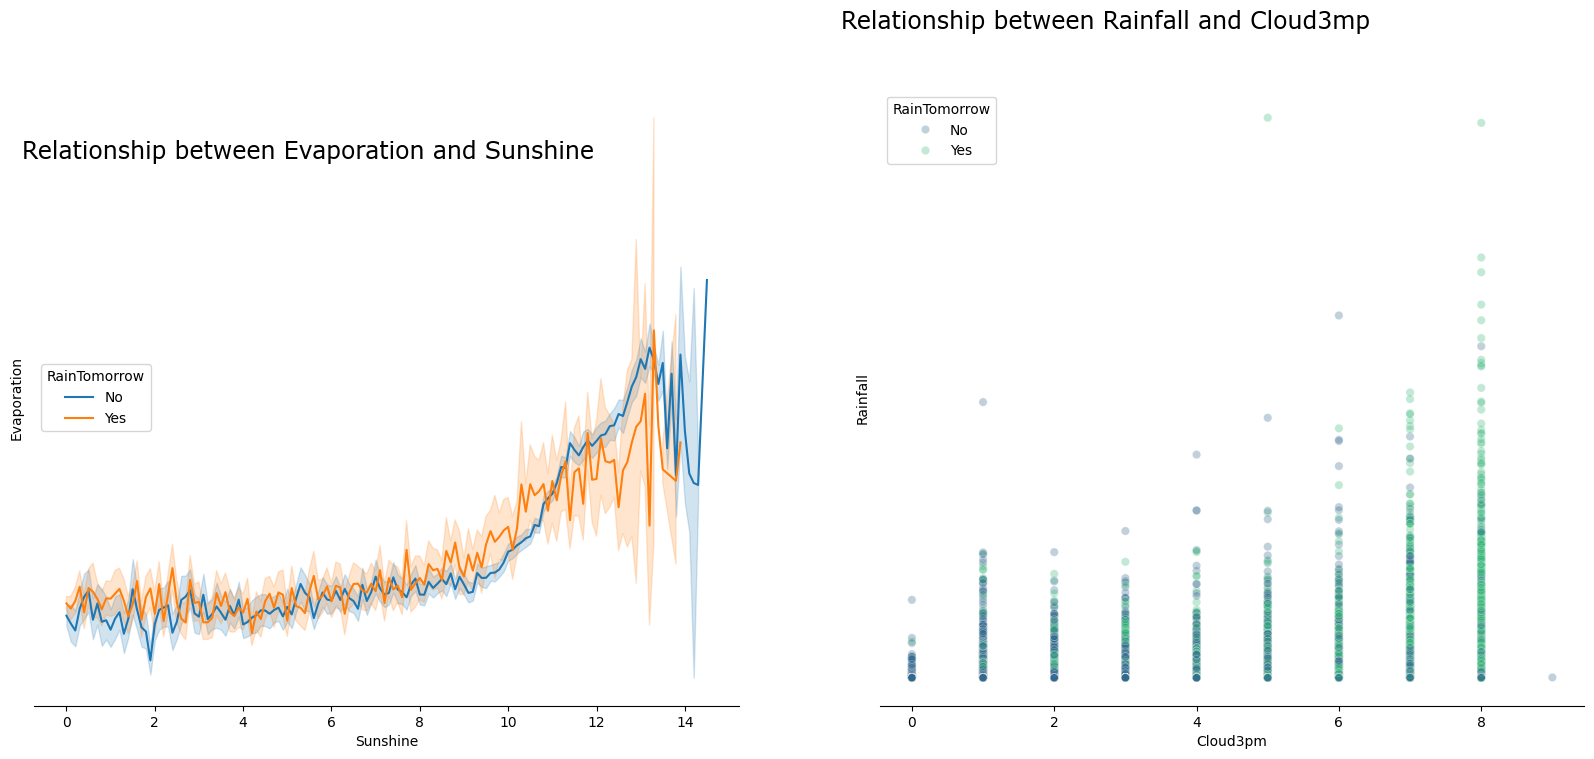

In [ ]:
# Визуализация зависимости между 'Evaporation' и 'Sunshine', а также 'Rainfall' и 'Cloud3pm'.
fig=plt.figure(figsize=(20,8),facecolor='white')

gs=fig.add_gridspec(1,2)

ax=[_ for i in range(2)]

ax[0]=fig.add_subplot(gs[0,0])
ax[1]=fig.add_subplot(gs[0,1])

ax[0].text(-1,15,"Relationship between Evaporation and Sunshine",fontsize=17,fontweight='normal', fontfamily='Verdana')

ax[1].text(-1,430,"Relationship between Rainfall and Cloud3mp",fontsize=17,fontweight='normal', fontfamily='Verdana')


for i in range(2):
    ax[i].set_yticklabels([])
    ax[i].tick_params(axis='y',length=0)
    
    for direction in ["top","right", 'left']:
        ax[i].spines[direction].set_visible(False)

sns.lineplot(data=class_data,x='Sunshine',y='Evaporation',ax=ax[0],hue='RainTomorrow')
sns.scatterplot(data=class_data,x='Cloud3pm',y='Rainfall',hue='RainTomorrow',ax=ax[1],palette='viridis',markers='o',alpha=0.3)

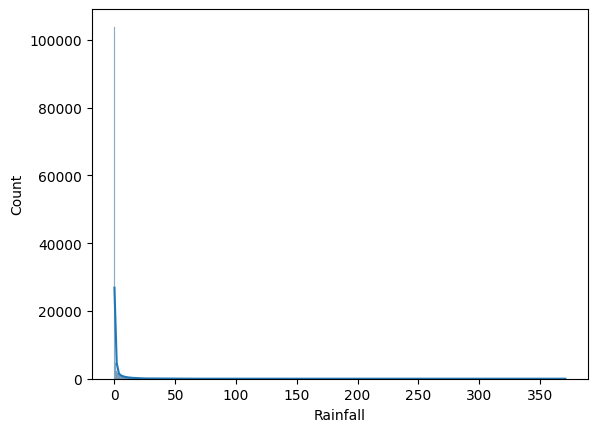

In [ ]:
# Визуализация распределения 'Rainfall'.
sns.histplot(data = class_data, x = 'Rainfall', bins = 'auto', kde = True)

<Axes: xlabel='MaxTemp', ylabel='Count'>

<Axes: xlabel='MaxTemp', ylabel='Count'>

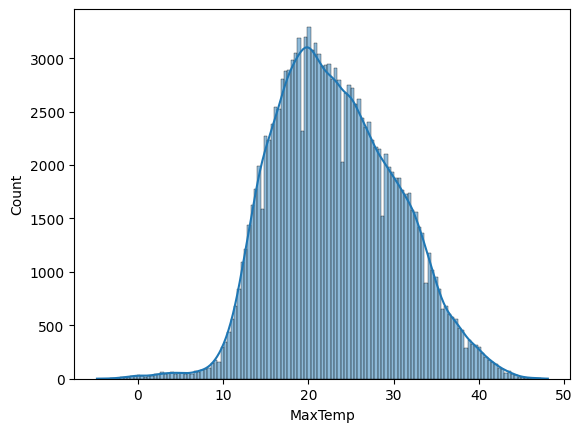

In [ ]:
# Визуализация распределения 'Rainfall'.
sns.histplot(data = class_data, x = 'MaxTemp', bins = 'auto', kde = True)

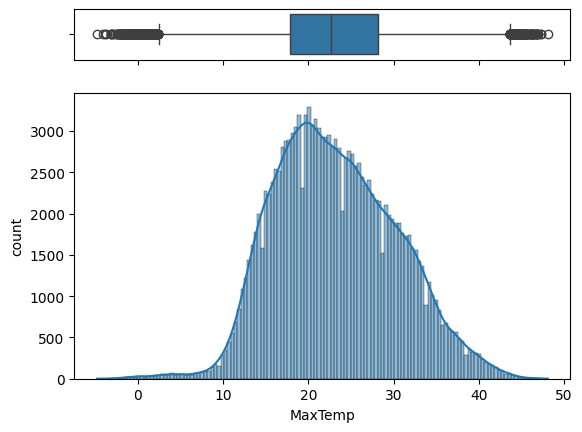

In [ ]:
# Визуализация распределения 'MaxTemp' с помощью boxplot и histogram.
fig, (ax_box, ax_hist) = plt.subplots(2, 
                                    sharex = True, 
                                    gridspec_kw = {'height_ratios': (.15, .85)}) 
 
sns.boxplot(x = class_data['MaxTemp'], ax = ax_box)
sns.histplot(x = class_data['MaxTemp'], ax = ax_hist, bins = 'auto', kde = True)
 
ax_box.set(xlabel = '') 
ax_hist.set(xlabel = 'MaxTemp')
ax_hist.set(ylabel = 'count')
 
plt.show()

<Axes: xlabel='RainTomorrow', ylabel='count'>

<Axes: xlabel='RainTomorrow', ylabel='count'>

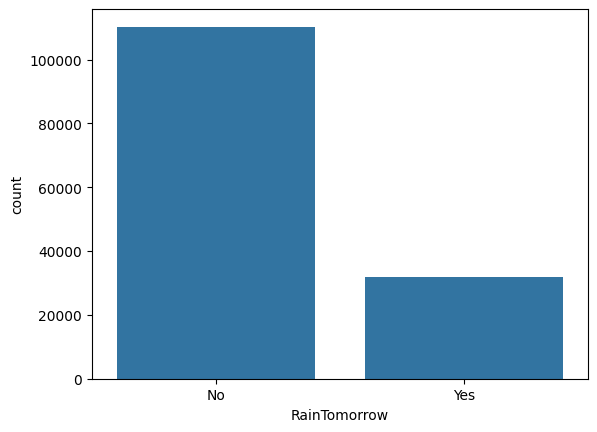

In [ ]:
# Визуализация распределения 'RainTomorrow'.
sns.countplot(x = 'RainTomorrow', data = class_data)

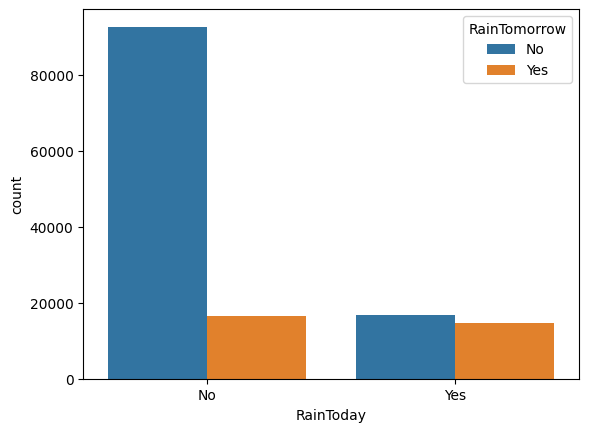

In [ ]:
# Визуализация распределения 'RainTomorrow'.
sns.countplot(x = 'RainToday', hue = 'RainTomorrow', data = class_data)

In [ ]:
# Разделение признаков на категориальные (str_cols) и числовые (num_cols).
str_cols = class_data.select_dtypes(include=['object']).columns.tolist()

print("Categorical variables:")
print(str_cols)

Categorical variables:
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [ ]:
# Подсчет пропущенных значений в категориальных признаках.
for i in str_cols:
    print(i, class_data[i].isnull().sum())

Date 0
Location 0
WindGustDir 10326
WindDir9am 10566
WindDir3pm 4228
RainToday 3261
RainTomorrow 3267


In [ ]:
# Заполнение пропущенных значений в категориальных признаках модой.
for i in str_cols:
    class_data[i].fillna(class_data[i].mode()[0], inplace=True)

In [ ]:
# Преобразование целевой переменной 'RainTomorrow' и признака 'RainToday' в числовой формат.
class_data['RainToday'].replace({'No': 0, 'Yes': 1},inplace = True)
class_data['RainTomorrow'].replace({'No': 0, 'Yes': 1},inplace = True)

/var/folders/d0/0j41qjnd51vdsqjbyvxmlgyh0000gn/T/ipykernel_1011/2048983535.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  class_data['RainToday'].replace({'No': 0, 'Yes': 1},inplace = True)
/var/folders/d0/0j41qjnd51vdsqjbyvxmlgyh0000gn/T/ipykernel_1011/2048983535.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  class_data['RainTomorrow'].replace({'No': 0, 'Yes': 1},inplace = True)


In [19]:
class_data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


In [ ]:
# Разделение признаков на категориальные (str_cols) и числовые (num_cols).
num_cols = class_data.select_dtypes(include=[np.number]).columns.tolist()

print("Neumeric variables:")
print(num_cols)

Neumeric variables:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [ ]:
# Подсчет пропущенных значений в числовых признаках.
for i in num_cols:
    print(i, class_data[i].isnull().sum())

MinTemp 1485
MaxTemp 1261
Rainfall 3261
Evaporation 62790
Sunshine 69835
WindGustSpeed 10263
WindSpeed9am 1767
WindSpeed3pm 3062
Humidity9am 2654
Humidity3pm 4507
Pressure9am 15065
Pressure3pm 15028
Cloud9am 55888
Cloud3pm 59358
Temp9am 1767
Temp3pm 3609
RainToday 0
RainTomorrow 0


In [ ]:
# Заполнение пропущенных значений в числовых признаках медианой.
for i in num_cols:
    class_data[i].fillna(class_data[i].median(), inplace=True)

In [23]:
class_data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0,0
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0,0
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0,0
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0,0
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


In [24]:
class_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [25]:
class_data.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [26]:
str_cols=class_data.select_dtypes(include='object').columns.to_list()
print(str_cols)

['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']


In [ ]:
# Удаление столбца 'Date', так как он не несет полезной информации для модели.
class_data.drop(columns='Date', inplace=True)

In [ ]:
# Проверка категориальных признаков после обработки пропущенных значений.
str_cols=class_data.select_dtypes(include='object').columns.to_list()
print(str_cols)

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']


<Axes: >

<Axes: >

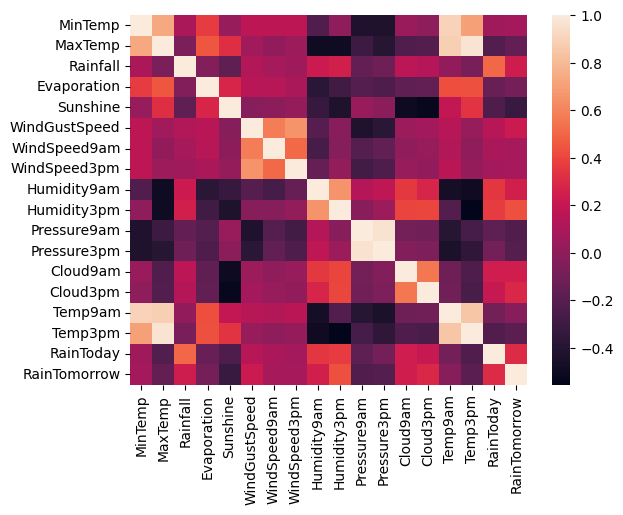

In [ ]:
# Визуализация корреляционной матрицы числовых признаков.
sns.heatmap(class_data.select_dtypes(include=[np.number]).corr())

In [ ]:
# Инициализация скейлера и кодировщика.
scaler = StandardScaler()
te = TargetEncoder()

In [ ]:
# Разделение на фичи и таргет
X, y = class_data.drop('RainTomorrow', axis=1), class_data['RainTomorrow']

In [ ]:
# Разделение признаков на категориальные (str_cols) и числовые (num_cols).
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
str_cols = X.select_dtypes(include=['object']).columns.tolist()

In [ ]:
# Создание трансформера для предобработки данных.
transformer = ColumnTransformer(transformers=[
    ('scaler', scaler, num_cols),
    ('cat', te, str_cols)
])

pipe = Pipeline([('preprocessing', transformer), ('model', KNeighborsClassifier())])

In [ ]:
# Разделение выборки на обучающую и тестовую.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred = pipe.predict(X_test)

Accuracy: 0.8297126357761584
F1 (binary): 0.5476625273922571
F1 (macro): 0.7213880048885404

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90     22672
           1       0.66      0.47      0.55      6420

    accuracy                           0.83     29092
   macro avg       0.76      0.70      0.72     29092
weighted avg       0.82      0.83      0.82     29092


Confusion matrix:
 [[21139  1533]
 [ 3421  2999]]

Class distribution (test):
RainTomorrow
0    22672
1     6420
Name: count, dtype: int64
Baseline (most frequent) accuracy: 0.7793207754709198

ROC AUC: 0.8108275135097405

ROC AUC: 0.8108275135097405


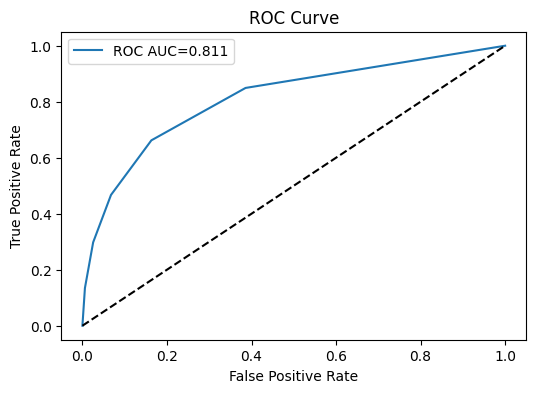

In [ ]:
# Оценка модели с использованием различных метрик.
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 (binary):', f1_score(y_test, y_pred))
print('F1 (macro):', f1_score(y_test, y_pred, average='macro'))
print('\nClassification report:\n', classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion matrix:\n', cm)

print('\nClass distribution (test):')
print(y_test.value_counts())
print('Baseline (most frequent) accuracy:', y_test.value_counts(normalize=True).max())

y_proba = pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print('\nROC AUC:', auc)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
# Создание своего класса KnnClassifier
class KnnClassifier:
    def __init__(self, n_neighbors=5, weights='uniform', p=2, leaf_size=30):
        if weights not in ('uniform', 'distance'):
            raise ValueError("weights must be 'uniform' or 'distance'")
        self.n_neighbors = int(n_neighbors)
        self.weights = weights
        self.p = p
        self.leaf_size = leaf_size

        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
        y_arr = y.values if hasattr(y, 'values') else np.asarray(y)

        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(-1, 1)

        self.X_train = X_arr.astype(float)
        self.y_train = y_arr.ravel().astype(int)

        return self
    
    def _dist_single(self, x):
        if self.p == 1:
            diff = np.abs(self.X_train - x)
            return diff.sum(axis=1)

        diff = self.X_train - x
        if self.p == 2:
            return np.sqrt((diff * diff).sum(axis=1))

        return np.sum(np.abs(diff) ** self.p, axis=1) ** (1.0 / self.p)

        
    def _predict_single(self, x):

        dists = self._dist_single(x)
        k = min(self.n_neighbors, len(dists))

        idx_part = np.argpartition(dists, k-1)[:k]
        neigh_dists = dists[idx_part]

        order = np.argsort(neigh_dists)
        neigh_idx = idx_part[order]
        neigh_dists_sorted = neigh_dists[order]

        neigh_y = self.y_train[neigh_idx]

        if self.weights == 'uniform':
            values, counts = np.unique(neigh_y, return_counts=True)
            return values[np.argmax(counts)]

        eps = 1e-8
        exact_mask = neigh_dists_sorted == 0

        if np.any(exact_mask):
            exact_labels = neigh_y[exact_mask]
            values, counts = np.unique(exact_labels, return_counts=True)
            return values[np.argmax(counts)]

        weights = 1.0 / (neigh_dists_sorted + eps)
        labels = np.unique(neigh_y)
        score = np.zeros(len(labels))

        for j, lbl in enumerate(labels):
            score[j] = weights[neigh_y == lbl].sum()

        return labels[np.argmax(score)]
    
    def predict(self, X):
        if self.X_train is None:
            raise RuntimeError("Model has not been fitted yet.")

        Xq = X.values if hasattr(X, 'values') else np.asarray(X)
        if Xq.ndim == 1:
            Xq = Xq.reshape(1, -1)

        preds = np.zeros(Xq.shape[0], dtype=int)

        for i, row in enumerate(Xq):
            preds[i] = self._predict_single(row)

        return preds
    
    def _predict_proba_single(self, x):
        dists = self._dist_single(x)
        k = min(self.n_neighbors, len(dists))

        idx_part = np.argpartition(dists, k-1)[:k]
        neigh_dists = dists[idx_part]

        order = np.argsort(neigh_dists)
        neigh_idx = idx_part[order]
        neigh_dists_sorted = neigh_dists[order]

        neigh_y = self.y_train[neigh_idx]

        classes = np.unique(self.y_train)
        proba = np.zeros(len(classes), dtype=float)

        if self.weights == 'uniform':
            for i, c in enumerate(classes):
                proba[i] = np.sum(neigh_y == c) / k
            return proba

        eps = 1e-8
        exact_mask = neigh_dists_sorted == 0

        if np.any(exact_mask):
            exact_labels = neigh_y[exact_mask]
            for i, c in enumerate(classes):
                proba[i] = np.sum(exact_labels == c) / len(exact_labels)
            return proba

        weights = 1.0 / (neigh_dists_sorted + eps)

        for i, c in enumerate(classes):
            mask = (neigh_y == c)
            if np.any(mask):
                proba[i] = weights[mask].sum()

        s = proba.sum()
        if s > 0:
            proba /= s

        return proba


    def predict_proba(self, X):
        if self.X_train is None:
            raise RuntimeError("Model has not been fitted yet.")

        Xq = X.values if hasattr(X, 'values') else np.asarray(X)
        if Xq.ndim == 1:
            Xq = Xq.reshape(1, -1)

        classes = np.unique(self.y_train)
        proba_result = np.zeros((len(Xq), len(classes)), dtype=float)

        for i, row in enumerate(Xq):
            proba_result[i] = self._predict_proba_single(row)

        return proba_result


In [46]:
pipe_custom = Pipeline([('preprocessing', transformer), ('model', KnnClassifier(n_neighbors=5))])
pipe_custom.fit(X_train, y_train)
y_pred_custom = pipe_custom.predict(X_test)

/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Accuracy (pipe_custom): 0.8297126357761584
F1 (binary): 0.5477451159393829
F1 (macro): 0.7214270784016203

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90     22672
           1       0.66      0.47      0.55      6420

    accuracy                           0.83     29092
   macro avg       0.76      0.70      0.72     29092
weighted avg       0.82      0.83      0.82     29092


Confusion matrix:
 [[21138  1534]
 [ 3420  3000]]


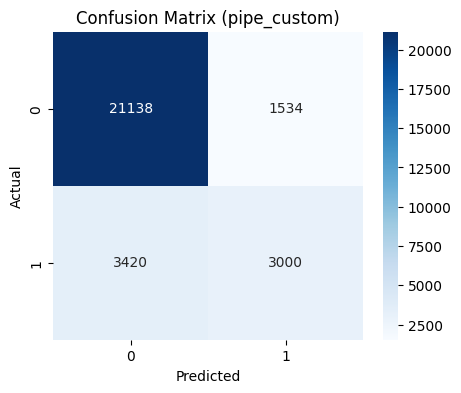

Accuracy (pipe_custom): 0.8297126357761584
F1 (binary): 0.5477451159393829
F1 (macro): 0.7214270784016203

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90     22672
           1       0.66      0.47      0.55      6420

    accuracy                           0.83     29092
   macro avg       0.76      0.70      0.72     29092
weighted avg       0.82      0.83      0.82     29092


Confusion matrix:
 [[21138  1534]
 [ 3420  3000]]


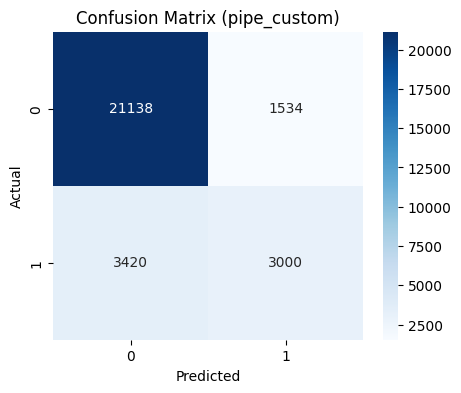


Class distribution (test):
RainTomorrow
0    22672
1     6420
Name: count, dtype: int64
Baseline (most frequent) accuracy: 0.7793207754709198

ROC AUC: 0.8109612334206135

ROC AUC: 0.8109612334206135


Accuracy (pipe_custom): 0.8297126357761584
F1 (binary): 0.5477451159393829
F1 (macro): 0.7214270784016203

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90     22672
           1       0.66      0.47      0.55      6420

    accuracy                           0.83     29092
   macro avg       0.76      0.70      0.72     29092
weighted avg       0.82      0.83      0.82     29092


Confusion matrix:
 [[21138  1534]
 [ 3420  3000]]


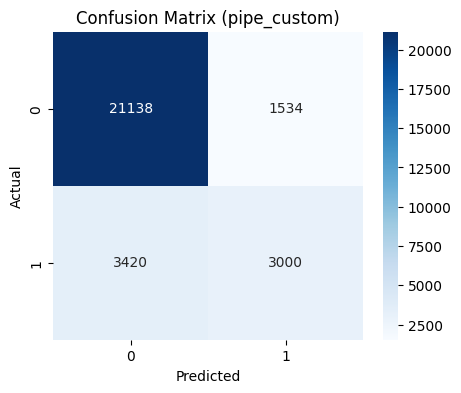


Class distribution (test):
RainTomorrow
0    22672
1     6420
Name: count, dtype: int64
Baseline (most frequent) accuracy: 0.7793207754709198

ROC AUC: 0.8109612334206135

ROC AUC: 0.8109612334206135


/Users/anatolii/Универ/ИИ_фреймворки/.venv/lib/python3.14/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


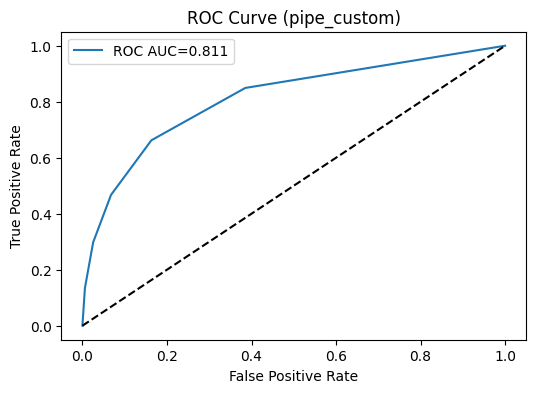

In [47]:
# Оценка качества pipe_custom
print('Accuracy (pipe_custom):', accuracy_score(y_test, y_pred_custom))
print('F1 (binary):', f1_score(y_test, y_pred_custom))
print('F1 (macro):', f1_score(y_test, y_pred_custom, average='macro'))
print('\nClassification report:\n', classification_report(y_test, y_pred_custom))

# Матрица неточностей и её визуализация
cm = confusion_matrix(y_test, y_pred_custom)
print('\nConfusion matrix:\n', cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (pipe_custom)')
plt.show()

print('\nClass distribution (test):')
print(y_test.value_counts())
print('Baseline (most frequent) accuracy:', y_test.value_counts(normalize=True).max())

y_proba = pipe_custom.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print('\nROC AUC:', auc)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (pipe_custom)')
plt.legend()
plt.show()



In [48]:
# Настроим RandomizedSearch для KNN (classification)
model = KNeighborsClassifier()

param_dist = {
    'model__n_neighbors': list(range(5,31)),
    'model__weights': ['uniform','distance'],
    'model__p': [1,2],
    'model__leaf_size': list(range(10,51))
}

rs = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=20, cv=5,
                    scoring='roc_auc', n_jobs=-1, random_state=42)


In [49]:
# Обучаем и выводим лучшие параметры и метрику по CV
rs.fit(X_train, y_train)
print('Best params:', rs.best_params_)
print('Best CV score (ROC AUC):', rs.best_score_)

Best params: {'model__weights': 'uniform', 'model__p': 1, 'model__n_neighbors': 29, 'model__leaf_size': 37}
Best CV score (ROC AUC): 0.8610377608996711


In [50]:
# Оценка на тестовой выборке
best_pipe = rs.best_estimator_
y_pred_rs = best_pipe.predict(X_test)

In [51]:
y_proba_rs = best_pipe.predict_proba(X_test)[:, 1]

Accuracy: 0.8407465970026125
F1 (binary): 0.5447577871671416
F1 (macro): 0.7241255138681126

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.90     22672
           1       0.74      0.43      0.54      6420

    accuracy                           0.84     29092
   macro avg       0.80      0.69      0.72     29092
weighted avg       0.83      0.84      0.82     29092


Confusion matrix:
 [[21687   985]
 [ 3648  2772]]


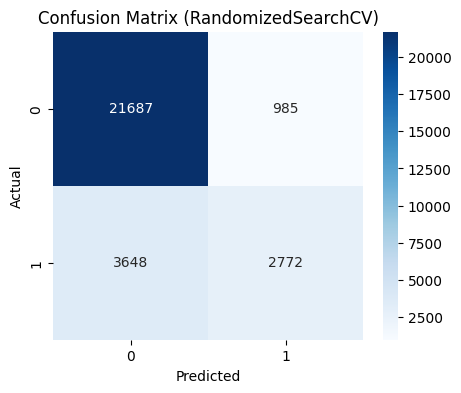


ROC AUC: 0.86237975960027


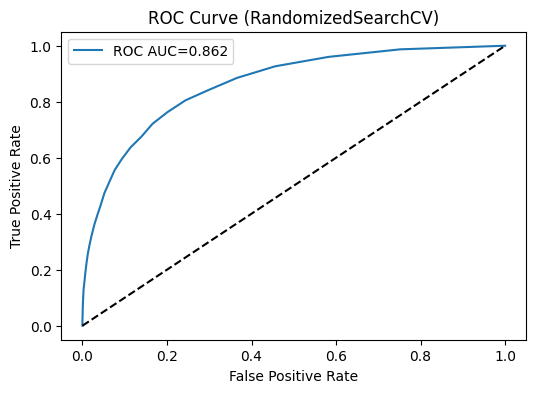

In [52]:
print('Accuracy:', accuracy_score(y_test, y_pred_rs))
print('F1 (binary):', f1_score(y_test, y_pred_rs))
print('F1 (macro):', f1_score(y_test, y_pred_rs, average='macro'))
print('\nClassification report:\n', classification_report(y_test, y_pred_rs))

cm = confusion_matrix(y_test, y_pred_rs)
print('\nConfusion matrix:\n', cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (RandomizedSearchCV)')
plt.show()

auc = roc_auc_score(y_test, y_proba_rs)
print('\nROC AUC:', auc)
fpr, tpr, _ = roc_curve(y_test, y_proba_rs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (RandomizedSearchCV)')
plt.legend()
plt.show()